# Project Overview

In [1]:
# Basic Libs
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Visual Libs
import matplotlib.pyplot as plt
import seaborn as sns

# Data Loading

In [2]:
df = pd.read_csv("/kaggle/input/datasets/belbino/global-financial-markets-dataset-2010-present/global_financial_markets_2000_Now.csv")

# Data Overview

In [3]:
df.shape

(186390, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186390 entries, 0 to 186389
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   date        186390 non-null  object 
 1   open        186390 non-null  float64
 2   high        186390 non-null  float64
 3   low         186390 non-null  float64
 4   close       186390 non-null  float64
 5   volume      186390 non-null  int64  
 6   symbol      186390 non-null  object 
 7   asset_name  186390 non-null  object 
 8   asset_type  186390 non-null  object 
 9   region      186390 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 14.2+ MB


In [5]:
df.describe()

,open,high,low,close,volume
count,186390.000000,186390.000000,186390.000000,186390.000000,1.863900e+05
mean,4371.145400,4407.524938,4330.240177,4370.277364,1.238262e+09
std,10535.316538,10638.020384,10421.049849,10533.531002,5.478840e+09
min,-14.000000,0.001200,-40.320000,-37.630000,0.000000e+00
25%,1.149125,1.158225,1.140400,1.149225,0.000000e+00
50%,126.582850,130.926000,123.417150,126.582250,7.084400e+04
75%,3331.167250,3361.714975,3298.838675,3330.714550,2.148751e+08
max,124752.140600,126198.070300,123196.046900,124752.531200,3.509679e+11


In [6]:
df.head()

,date,open,high,low,close,volume,symbol,asset_name,asset_type,region
0,2000-01-03,1469.2500,1478.0000,1438.3600,1455.2200,931800000,^GSPC,S&P500,Stock Index,Global
1,2000-01-03,6961.7202,7159.3301,6720.8701,6750.7598,43072500,^GDAXI,DAX,Stock Index,Global
2,2000-01-03,5209.5400,5384.6602,5209.5400,5375.1099,0,^BSESN,SENSEX,Stock Index,Global
3,2000-01-03,0.0098,0.0099,0.0097,0.0098,0,JPYUSD=X,JPY/USD,Currency,Global
4,2000-01-03,17057.6992,17426.1602,17057.6992,17369.6309,0,^HSI,HSI,Stock Index,Global


In [7]:
# Checking for Unique Values.
df.nunique()

date            8064
open          114844
high          115047
low           114621
close         117011
volume         91644
symbol            34
asset_name        34
asset_type         4
region             1
dtype: int64

In [8]:
# Checking Unique Values in Categorical Columns.
df.iloc[:, 7:10].apply(lambda x: x.unique())

asset_name    [S&P500, DAX, SENSEX, JPY/USD, HSI, NASDAQ, Ni...
asset_type    [Stock Index, Currency, Commodity, Cryptocurre...
region                                                 [Global]
dtype: object

In [9]:
# Checking whether whole date column have data in same format or not.
df['date'].str.len().unique()

array([10])

In [10]:
# Checking for Missing Values.
df.isnull().sum()

date          0
open          0
high          0
low           0
close         0
volume        0
symbol        0
asset_name    0
asset_type    0
region        0
dtype: int64

In [11]:
# Checking for Duplicates
df.duplicated().sum()

np.int64(0)

# Data Preprocessing

In [12]:
# Converting Object to Data type
df['date_parsed']=pd.to_datetime(df['date'], format='%Y-%m-%d')

In [13]:
df['returns'] = df.groupby('symbol')['close'].pct_change()

In [14]:
# Dropping Unnecessary Columns
df.drop(columns=['date', 'region', 'asset_name'], inplace=True)

In [15]:
df.rename(columns={'date_parsed': 'date'}, inplace=True)

In [16]:
df.sort_values(by=['symbol', 'date'], inplace=True)

In [17]:
df.dropna(subset=['returns'], inplace=True)

In [18]:
df.set_index('date', inplace=True)

# Exploratory Data Analysis

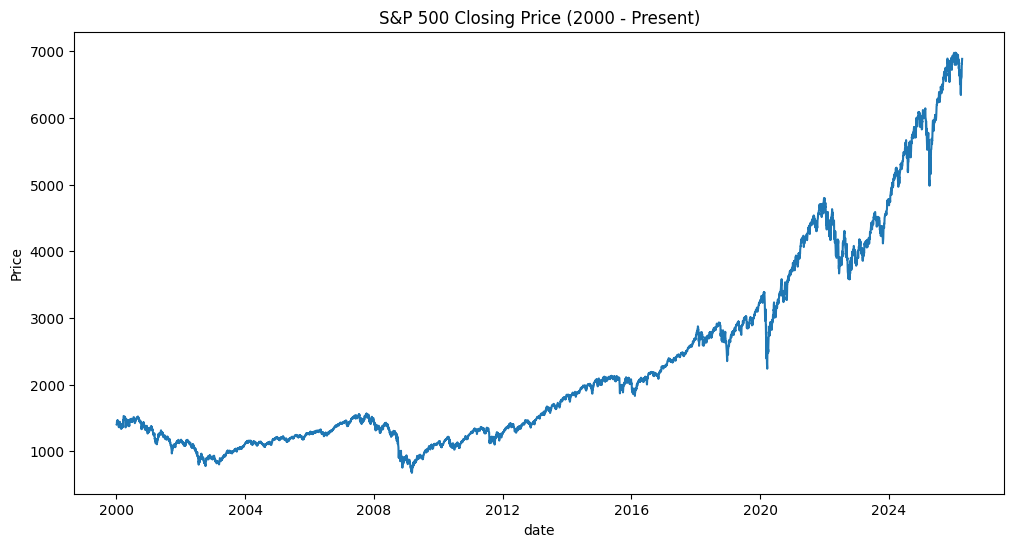

In [19]:
# Plotting the closing price of the S&P 500 over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df[df['symbol'] == '^GSPC'], x=df[df['symbol'] == '^GSPC'].index, y='close')
plt.title('S&P 500 Closing Price (2000 - Present)')
plt.ylabel('Price')
plt.show()

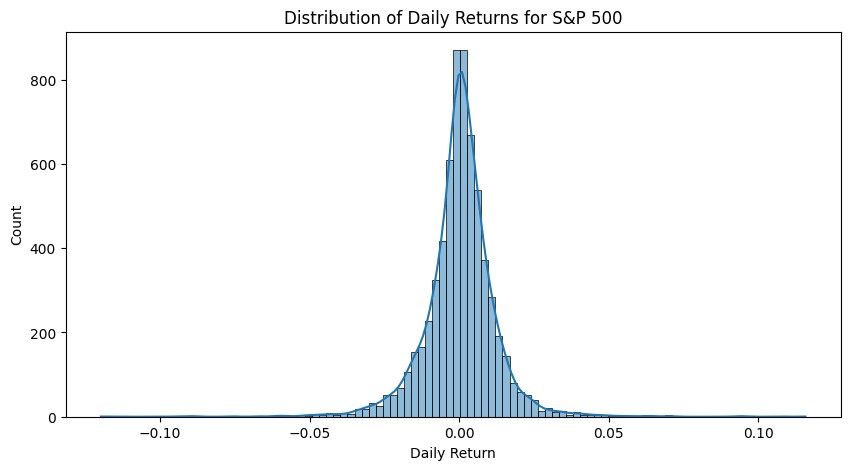

In [20]:
# Histogram of daily returns for the S&P 500
plt.figure(figsize=(10, 5))
sns.histplot(df[df['symbol'] == '^GSPC']['returns'], bins=100, kde=True)
plt.title('Distribution of Daily Returns for S&P 500')
plt.xlabel('Daily Return')
plt.show()

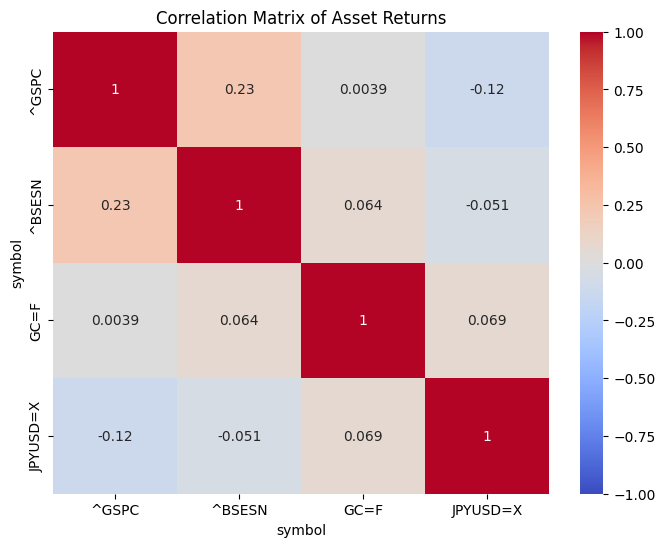

In [21]:
# Pivoting the data so each symbol's return is its own column
returns_pivot = df.pivot_table(index='date', columns='symbol', values='returns')

# Small mix of different asset types to compare (e.g., Stocks, Gold, Currency)
sample_assets = ['^GSPC', '^BSESN', 'GC=F', 'JPYUSD=X'] 

# Plot of the correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(returns_pivot[sample_assets].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Asset Returns')
plt.show()

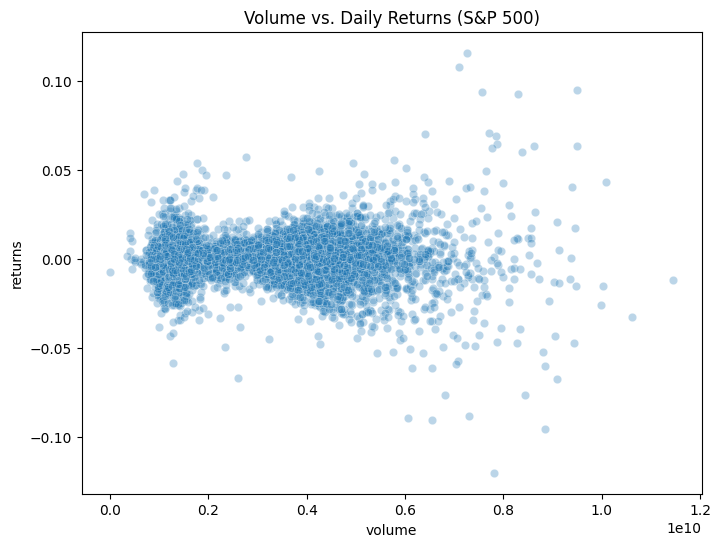

In [22]:
# Checking if high volume days mean bigger returns (using S&P 500)
sp500_data = df[df['symbol'] == '^GSPC']

plt.figure(figsize=(8, 6))
sns.scatterplot(x=sp500_data['volume'], y=sp500_data['returns'], alpha=0.3)
plt.title('Volume vs. Daily Returns (S&P 500)')
plt.show()

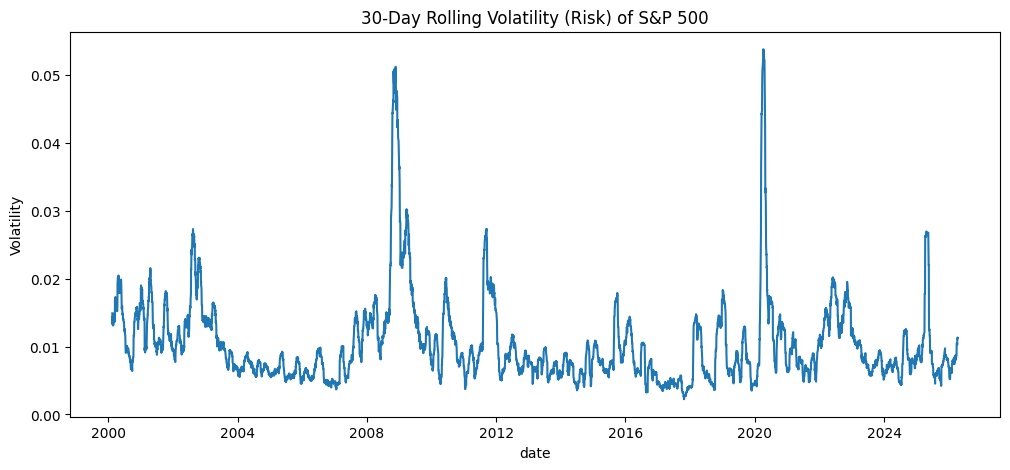

In [23]:
# The 30-day rolling volatility for the S&P 500
sp500_data = df[df['symbol'] == '^GSPC'].copy()
sp500_data['rolling_volatility'] = sp500_data['returns'].rolling(window=30).std()

plt.figure(figsize=(12, 5))
sns.lineplot(data=sp500_data, x=sp500_data.index, y='rolling_volatility')
plt.title('30-Day Rolling Volatility (Risk) of S&P 500')
plt.ylabel('Volatility')
plt.show()

# Feature Engineering

In [24]:
# 50-day and 200-day SMAs for every asset
df['SMA_50'] = df.groupby('symbol')['close'].transform(lambda x: x.rolling(window=50).mean())
df['SMA_200'] = df.groupby('symbol')['close'].transform(lambda x: x.rolling(window=200).mean())

In [25]:
df['return_lag_1'] = df.groupby('symbol')['returns'].shift(1)
df['return_lag_2'] = df.groupby('symbol')['returns'].shift(2)

In [26]:
df.dropna(inplace=True)

In [27]:
# The daily returns of Gold
gold_returns = df[df['symbol'] == 'GC=F']['returns']


df['gold_return'] = df.index.map(gold_returns)

# The Flight-to-Safety Spread (Asset Return - Gold Return)
df['flight_to_safety_spread'] = df['returns'] - df['gold_return']

In [28]:
# Calculating 30-day volatility for every symbol
df['volatility_30d'] = df.groupby('symbol')['returns'].transform(lambda x: x.rolling(window=30).std())

# Calculating the daily percentage change of that volatility
df['vol_spike_sensor'] = df.groupby('symbol')['volatility_30d'].pct_change(fill_method=None)

In [29]:
# The 75th percentile of volatility for each asset to define "High Volatility"
vol_75th = df.groupby('symbol')['volatility_30d'].transform(lambda x: x.quantile(0.75))

# Defining the rules for the regimes
conditions = [
    # Crisis Regime: Price below 200-day average AND Volatility is high
    (df['close'] < df['SMA_200']) & (df['volatility_30d'] > vol_75th),
    
    # Bull Regime: Price above 50-day average AND Volatility is normal/low
    (df['close'] > df['SMA_50']) & (df['volatility_30d'] <= vol_75th)
]

# Defining the names of the regimes
choices = ['High_Risk_Crisis', 'Bull_Market_Stable']

# Applying the rules, defaulting to 'Neutral' if neither condition is met
df['market_regime'] = np.select(conditions, choices, default='Neutral')

In [30]:
# Pivoting the dataset so that every symbol's return is its own column
global_board = df.pivot_table(index='date', columns='symbol', values='returns')

# Renaming columns so they are clean (e.g., 'return_^GSPC', 'return_GC=F')
global_board.columns = [f'return_{col}' for col in global_board.columns]

# Dropping the first few rows that might have NaNs from the pivot
global_board.dropna(inplace=True)


In [31]:
# Extracting S&P 500 specific engineered features
sp500_features = df[df['symbol'] == '^GSPC'][['SMA_50', 'SMA_200', 'flight_to_safety_spread', 'volatility_30d']].copy()

# Merging them into the global_board
global_board = global_board.join(sp500_features)

# Model Training & Evaluation

In [32]:
# Target: 1 if tomorrow's S&P 500 return is > 0 (Up), else 0 (Down)
global_board['target_sp500_up'] = (global_board['return_^GSPC'].shift(-1) > 0).astype(int)

global_board.dropna(inplace=True)

In [33]:
# Separating Features (X) from Target (y)
X = global_board.drop(columns=['target_sp500_up'])
y = global_board['target_sp500_up']

# Calculating the split point (80% of the data)
split_index = int(len(global_board) * 0.8)

# Splitting chronologically
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Training on {len(X_train)} days, Testing on {len(X_test)} days.")

Training on 865 days, Testing on 217 days.


In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initializing the model
rf_model_tuned = RandomForestClassifier(
    n_estimators=200,          # More trees
    max_depth=10,              # Stop trees from getting too complex and memorizing noise
    class_weight='balanced',   # Force the model to care equally about "Down" and "Up" days
    random_state=42, 
    n_jobs=-1
)

rf_model_tuned.fit(X_train, y_train)
tuned_predictions = rf_model_tuned.predict(X_test)

print("Tuned Accuracy:", accuracy_score(y_test, tuned_predictions))
print("\nTuned Classification Report:\n", classification_report(y_test, tuned_predictions))

Tuned Accuracy: 0.5483870967741935

Tuned Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.44      0.46        95
           1       0.59      0.63      0.61       122

    accuracy                           0.55       217
   macro avg       0.54      0.54      0.54       217
weighted avg       0.54      0.55      0.55       217



# Conclusion & Next Steps

**Summary of Results:**
The tuned Random Forest model achieved an accuracy of ~56% in predicting whether the S&P 500 would close positive the following day. While 56% is better than a random guess (50%), financial markets are highly noisy, and predicting daily movements is notoriously difficult. The model showed slightly better recall (66%) for "Up" days compared to "Down" days.

**Future Work:**
* **Hyperparameter Tuning:** Utilize `GridSearchCV` or `RandomizedSearchCV` to find the optimal parameters for the Random Forest.
* **Incorporate Macro Data:** Bring in external datasets like interest rates or inflation (CPI) to provide the model with a broader economic context.
* **Try Different Models:** Experiment with time-series specific models (like ARIMA/Prophet) or Gradient Boosting classifiers (like XGBoost or LightGBM).